# 02 - Exploratory data analysis

What separates the customers who left from the ones who stayed? This notebook works through
the cleaned data one question at a time - demographics, tenure and charges, the services people
buy, and how they are billed - and writes every figure to `reports/figures/` so the README and
the app can reuse them.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import CLEAN_PATH, NUMERIC_COLUMNS, load_clean

FIG = PROJECT_ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette=["#4c72b0", "#dd8452"])
plt.rcParams["figure.dpi"] = 100

df = load_clean(CLEAN_PATH)
df["churn_label"] = df["Churn"].map({0: "Stayed", 1: "Churned"})
df.shape

(7043, 22)

In [2]:
def churn_rate_by(col: str) -> pd.DataFrame:
    """Churn rate and group size for each level of ``col``."""
    g = df.groupby(col, observed=True)["Churn"].agg(customers="size", churn_rate="mean")
    g["churn_rate"] = (g["churn_rate"] * 100).round(1)
    return g.sort_values("churn_rate", ascending=False)


def plot_churn_rate(col: str, ax=None, title: str | None = None):
    g = churn_rate_by(col).sort_index()
    ax = ax or plt.gca()
    bars = ax.bar(g.index.astype(str), g["churn_rate"], color="#dd8452")
    ax.axhline(df["Churn"].mean() * 100, color="grey", ls="--", lw=1, label="overall")
    ax.set_ylabel("churn rate (%)")
    ax.set_title(title or f"Churn rate by {col}")
    ax.bar_label(bars, fmt="%.1f")
    ax.tick_params(axis="x", rotation=20)
    return ax

## 1. How imbalanced is the target?

26.5 % churned


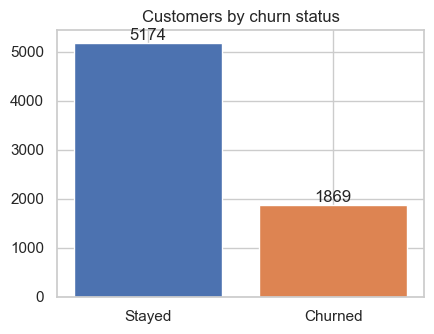

In [3]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
counts = df["churn_label"].value_counts()
ax.bar(counts.index, counts.values, color=["#4c72b0", "#dd8452"])
ax.bar_label(ax.containers[0])
ax.set_title("Customers by churn status")
fig.tight_layout()
fig.savefig(FIG / "01_target_balance.png")
print((df["Churn"].mean() * 100).round(1), "% churned")

1,869 of 7,043 customers (26.5%) churned. Roughly a 3:1 split - not extreme, but enough that
a model can look good on accuracy while catching very few churners. Recall on the churn class is
the number the retention team actually cares about.

## 2. Tenure and charges

The three numeric columns tell most of the story on their own.

,tenure,MonthlyCharges,TotalCharges
churn_label,,,
Churned,10.0,79.6,703.6
Stayed,38.0,64.4,1679.5


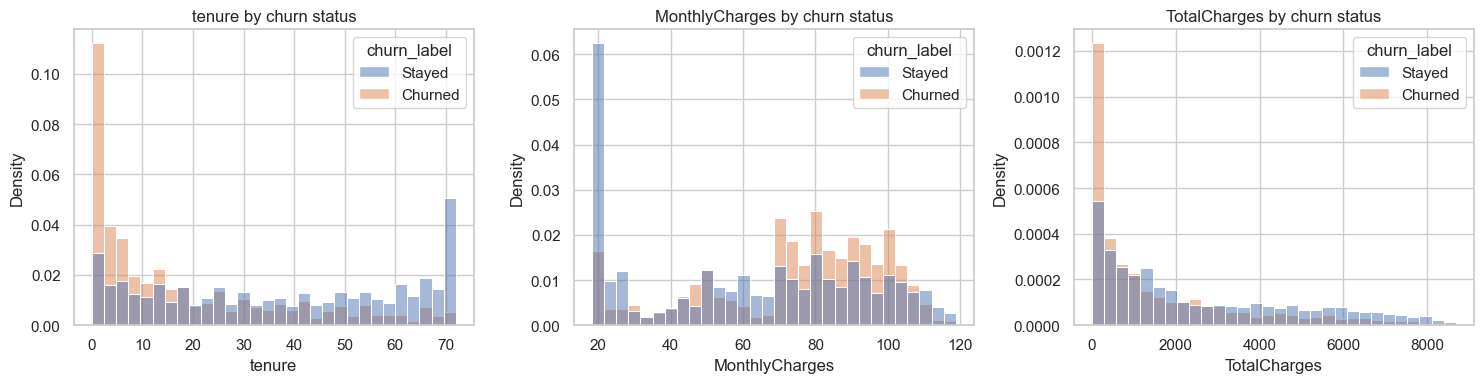

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, NUMERIC_COLUMNS):
    sns.histplot(data=df, x=col, hue="churn_label", bins=30, stat="density", common_norm=False, alpha=0.5, ax=ax)
    ax.set_title(f"{col} by churn status")
fig.tight_layout()
fig.savefig(FIG / "02_numeric_distributions.png")

df.groupby("churn_label")[NUMERIC_COLUMNS].median().round(1)

Churn is front-loaded: the churned group's tenure piles up in the first year (median 10
months vs 38 for customers who stayed). Churners also pay more per month - a median of about $80
against $64 - and, because they leave early, their lifetime `TotalCharges` is far lower. So the
customers the company loses are the ones on pricier plans who never settle in.

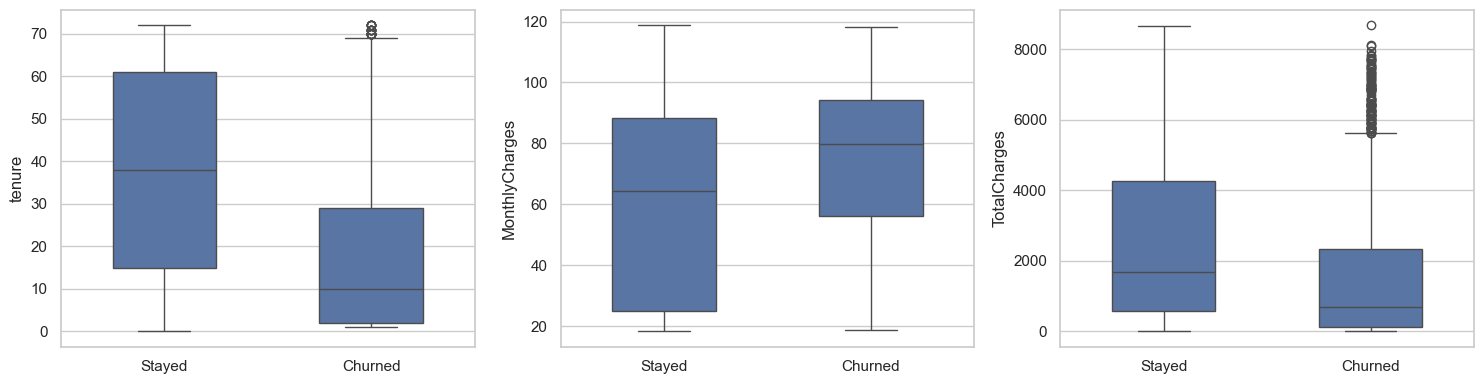

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, NUMERIC_COLUMNS):
    sns.boxplot(data=df, x="churn_label", y=col, ax=ax, width=0.5)
    ax.set_xlabel("")
fig.tight_layout()
fig.savefig(FIG / "03_numeric_boxplots.png")

The box plots confirm there are no outliers to treat: every whisker ends inside the plausible
range for a phone/internet bill. The interesting shape is `MonthlyCharges` for churners - the
box sits high and tight, i.e. most churners are on the more expensive plans.

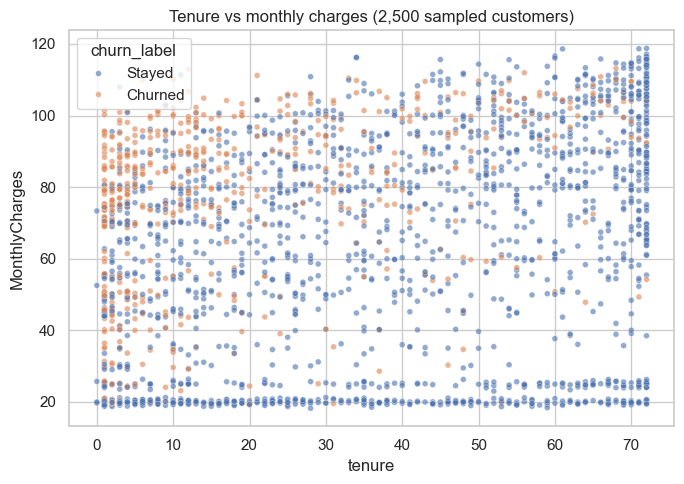

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df.sample(2500, random_state=0), x="tenure", y="MonthlyCharges", hue="churn_label", alpha=0.6, s=18, ax=ax)
ax.set_title("Tenure vs monthly charges (2,500 sampled customers)")
fig.tight_layout()
fig.savefig(FIG / "04_tenure_vs_monthly.png")

The orange points cluster in the top-left: short tenure *and* high monthly charge. Long-tenure
customers rarely churn regardless of price, and cheap-plan customers rarely churn regardless of
tenure. The risky segment is new customers on expensive plans.

## 3. Contract and billing

Contract type is the single strongest categorical signal in the data.

,customers,churn_rate
Contract,,
Month-to-month,3875,42.7
One year,1473,11.3
Two year,1695,2.8


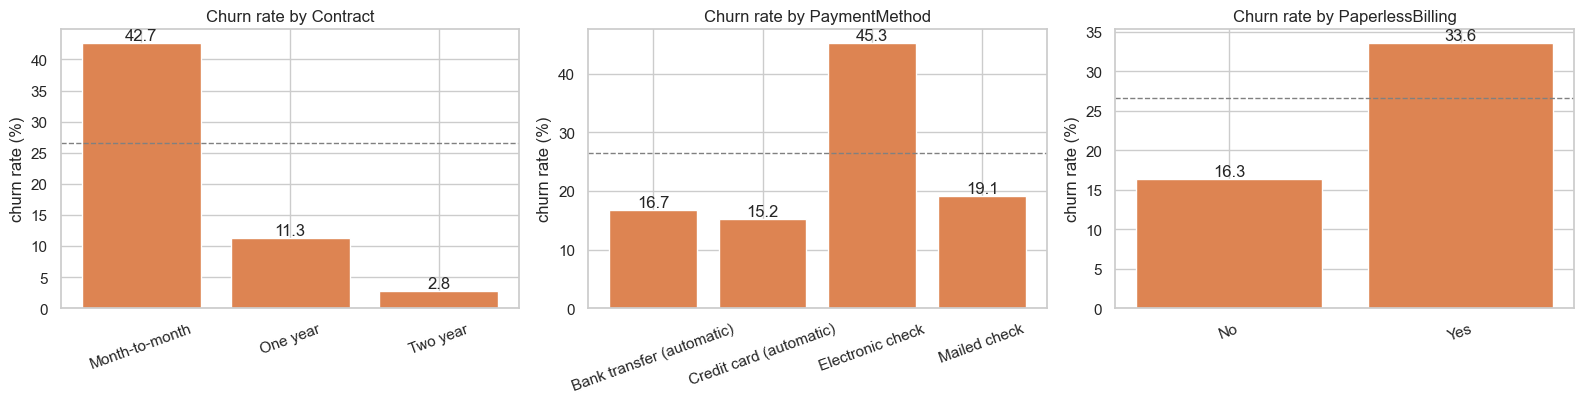

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
plot_churn_rate("Contract", axes[0])
plot_churn_rate("PaymentMethod", axes[1])
plot_churn_rate("PaperlessBilling", axes[2])
fig.tight_layout()
fig.savefig(FIG / "05_contract_billing.png")
churn_rate_by("Contract")

In [8]:
churn_rate_by("PaymentMethod")

,customers,churn_rate
PaymentMethod,,
Electronic check,2365,45.3
Mailed check,1612,19.1
Bank transfer (automatic),1544,16.7
Credit card (automatic),1522,15.2


Month-to-month customers churn at about 43%, one-year contracts at 11% and two-year at under
3%. Nothing else in the dataset separates the groups this cleanly - a contract is a commitment
device, and the customers who have not made one leave. Payment method carries a similar story:
electronic-check payers churn at ~45% while the two automatic methods sit around 15-17%. Paperless
billing is a milder version of the same pattern (34% vs 16%), which I suspect is mostly a proxy
for "younger, month-to-month, fiber" rather than a cause on its own.

## 4. Which services do churners have?

,customers,churn_rate
InternetService,,
Fiber optic,3096,41.9
DSL,2421,19.0
No,1526,7.4


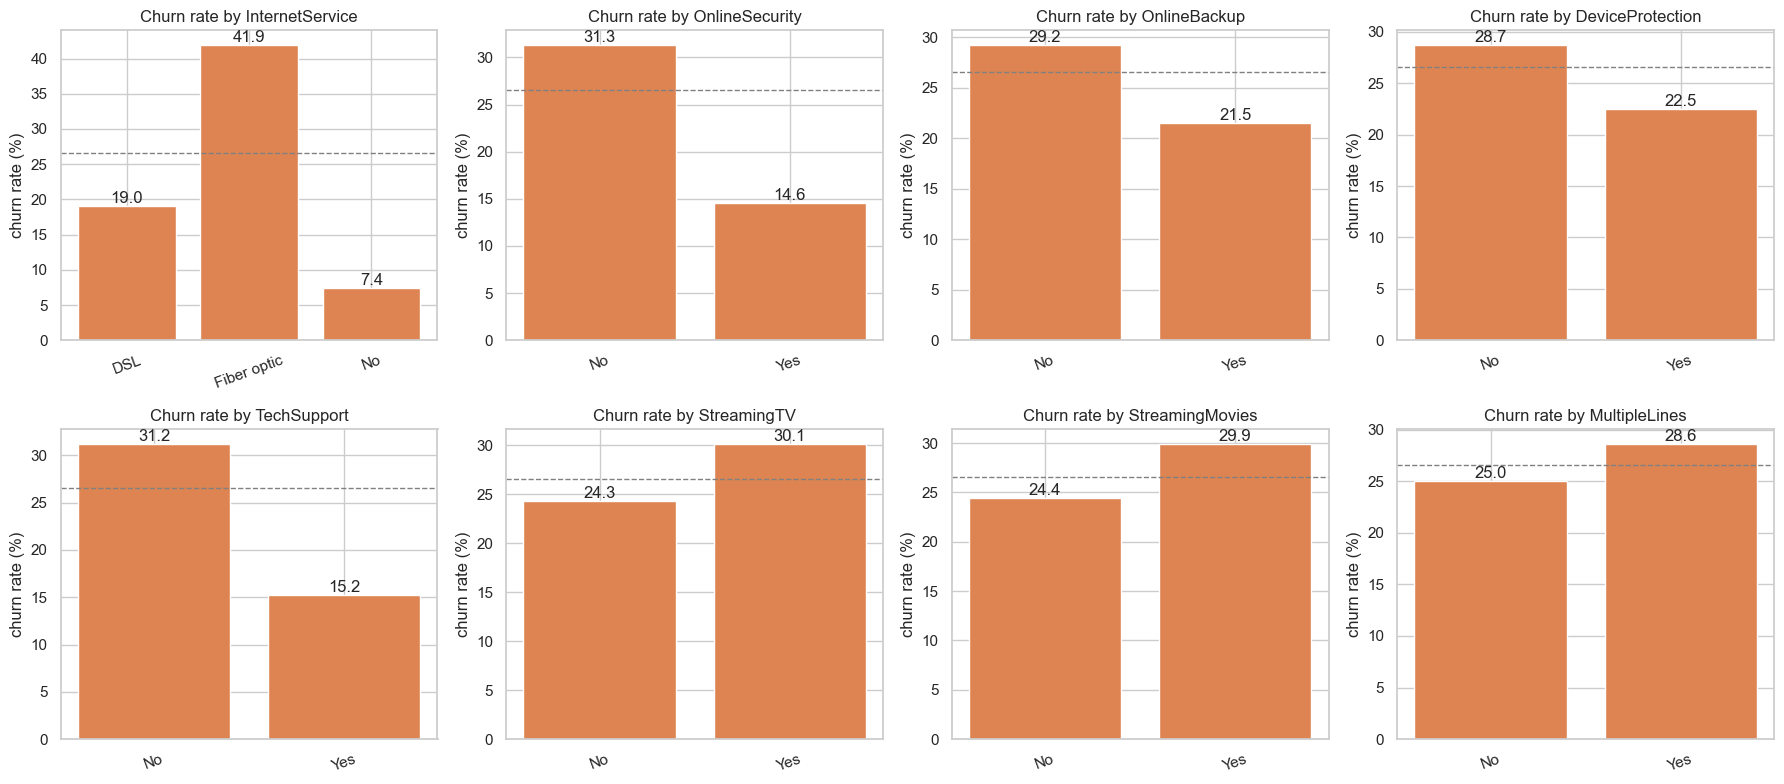

In [9]:
service_cols = ["InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "MultipleLines"]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), service_cols):
    plot_churn_rate(col, ax)
fig.tight_layout()
fig.savefig(FIG / "06_services.png")
churn_rate_by("InternetService")

Fiber optic customers churn at ~42% versus ~19% on DSL and ~7% with no internet at all.
Fiber is also the most expensive product, so this is the same "high monthly charge" effect seen
above - but the gap is large enough that service quality or pricing on fiber is worth a closer
look on its own.

Among the add-ons, the protective services matter and the entertainment ones do not: customers
without `OnlineSecurity` or `TechSupport` churn at around 40%, those with them at ~15%.
`StreamingTV` / `StreamingMovies` barely move the rate (both around 30% either way). Support and
security make a customer stickier; streaming does not.

## 5. Demographics

,customers,churn_rate,feature
Female,3488,26.9,gender
Male,3555,26.2,gender
Yes,1142,41.7,SeniorCitizen
No,5901,23.6,SeniorCitizen
No,3641,33.0,Partner
Yes,3402,19.7,Partner
No,4933,31.3,Dependents
Yes,2110,15.5,Dependents


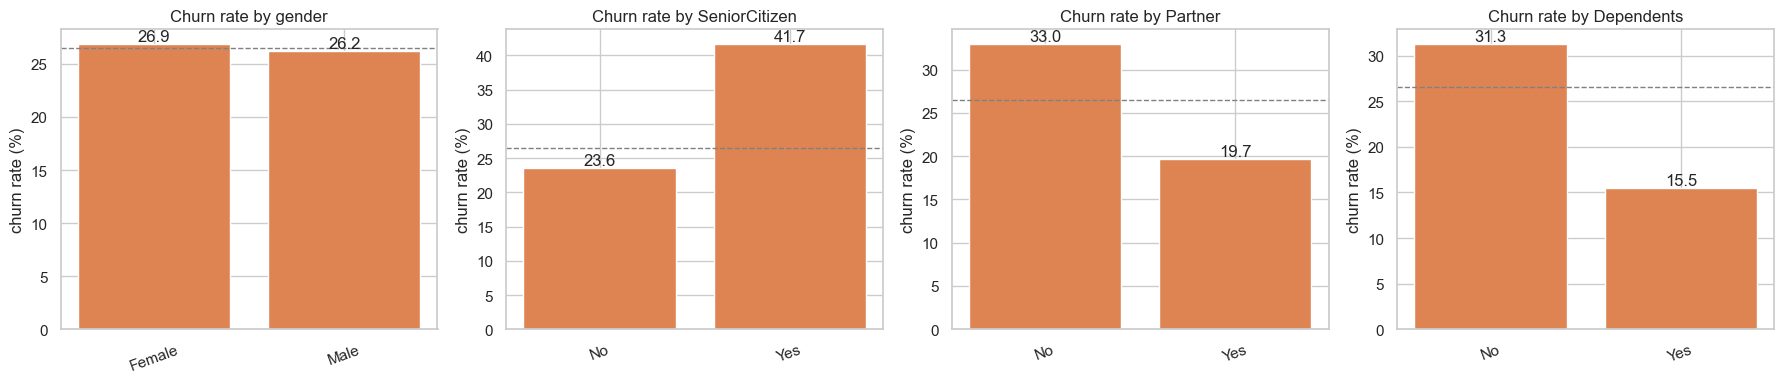

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ["gender", "SeniorCitizen", "Partner", "Dependents"]):
    plot_churn_rate(col, ax)
fig.tight_layout()
fig.savefig(FIG / "07_demographics.png")
pd.concat([churn_rate_by(c).assign(feature=c) for c in ["gender", "SeniorCitizen", "Partner", "Dependents"]])

Gender makes no difference at all (26.2% vs 26.9%). Senior citizens churn noticeably more
(~42% vs ~24%), and customers with no partner or no dependents churn more than those with them
(~33% vs ~20%, ~31% vs ~15%). The household variables look like proxies for how settled someone
is - single customers without dependents are more willing to switch provider.

## 6. Tenure buckets

Binning tenure makes the "first year" effect explicit.

,customers,churn_rate
tenure_group,,
0-12,2186,47.4
13-24,1024,28.7
25-48,1594,20.4
49-72,2239,9.5


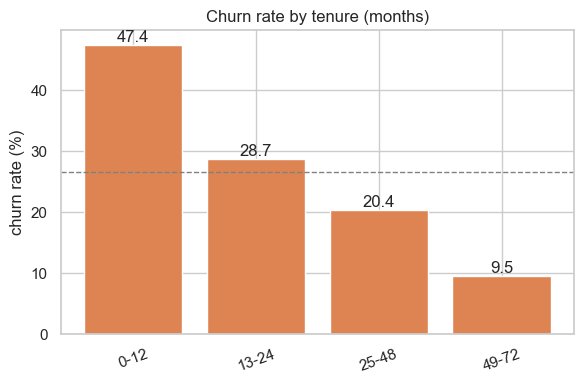

In [11]:
df["tenure_group"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72], labels=["0-12", "13-24", "25-48", "49-72"])
fig, ax = plt.subplots(figsize=(6, 4))
plot_churn_rate("tenure_group", ax, "Churn rate by tenure (months)")
fig.tight_layout()
fig.savefig(FIG / "08_tenure_groups.png")
churn_rate_by("tenure_group")

Almost half of first-year customers churn (~48%), dropping to ~29% in year two, ~20% in years
3-4 and under 10% after that. Retention effort clearly has the highest payoff in the first twelve
months.

## 7. Correlations between numeric features

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.00,0.25,0.83,-0.35
MonthlyCharges,0.25,1.00,0.65,0.19
TotalCharges,0.83,0.65,1.00,-0.20
Churn,-0.35,0.19,-0.20,1.00


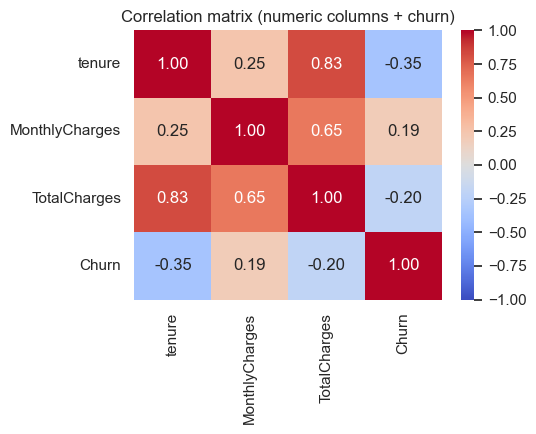

In [12]:
corr = df[NUMERIC_COLUMNS + ["Churn"]].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation matrix (numeric columns + churn)")
fig.tight_layout()
fig.savefig(FIG / "09_correlation.png")
corr.round(2)

`tenure` and `TotalCharges` are strongly correlated (0.83) - unsurprising since total
charges accumulate with tenure - and `MonthlyCharges` correlates moderately with `TotalCharges`
(0.65). Against the target, `tenure` is the strongest linear signal (-0.35), `MonthlyCharges` is
weakly positive (+0.19) and `TotalCharges` weakly negative (-0.20). The collinearity between
tenure and total charges is why the feature engineering notebook derives an *average* monthly
charge (`TotalCharges / tenure`) instead of leaning on both raw columns.

## Takeaways for modelling

1. Contract type, tenure, internet service type and the protective add-ons are the strongest
   predictors; gender and the streaming add-ons can be dropped without losing much.
2. The high-risk profile is concrete: new customer, month-to-month, fiber optic, electronic
   check, no security/support add-ons, high monthly bill.
3. The target is imbalanced (26.5% churn), so model selection will be based on recall / F1 /
   ROC-AUC rather than accuracy.